# Daily Challenge — Strategic Analysis of Superstore Performance
## Week 2 — Day 4

Business-intelligence report on the **US Superstore dataset**. The notebook follows the structure:
1. Data scoping & preparation
2. Deep-dive exploratory analysis (Matplotlib + ipywidgets)
3. Communicating insights (Seaborn)
4. Methodology review (Matplotlib vs Seaborn)
5. Executive summary & advanced challenges

All comments are in English.

## 1. Data Scoping and Preparation

In [1]:
# ==================== IMPORTS ====================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ipywidgets gives us interactive dropdowns and sliders inside the notebook
try:
    import ipywidgets as widgets
    from ipywidgets import interact, Dropdown, IntSlider
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
    print('ipywidgets is not available — interactive cells will fall back to static plots.')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
BASE_DIR = os.getcwd()

ipywidgets is not available — interactive cells will fall back to static plots.


In [2]:
# ==================== LOAD DATASET ====================
# The CSV uses ISO-8859-1 (latin-1) encoding because of accented product names.
df = pd.read_csv(os.path.join(BASE_DIR, 'superstore_dataset.csv'), encoding='latin-1')

# Basic data exploration
print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
df.head()

Dataset Shape: (51290, 24)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High
3,11731,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High
4,22255,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium


In [3]:
# Column dtypes, descriptive stats and missing values report
df.info()
print('\nNumerical summary:')
display(df.describe())
print('\nMissing values per column:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000



Missing values per column:
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64


In [4]:
# ==================== CLEANING ====================
# 1) Drop fully duplicated rows (if any).
print('Duplicate rows before cleaning:', df.duplicated().sum())
df = df.drop_duplicates()

# 2) Postal Code has many missing values for non-US rows. We fill with 0 to keep the column.
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

# 3) Restrict the analysis to the United States (the challenge talks about *US* Superstore).
if 'Country' in df.columns:
    df = df[df['Country'] == 'United States'].copy()

print('Shape after cleaning + US filter:', df.shape)
print('Remaining missing values:\n', df.isnull().sum().sort_values(ascending=False).head())

Duplicate rows before cleaning: 0
Shape after cleaning + US filter: (9994, 24)
Remaining missing values:
 Row ID        0
Order ID      0
Order Date    0
Ship Date     0
Ship Mode     0
dtype: int64


### Justification of cleaning choices
- **Duplicates** are removed because they would inflate sales and profit totals.
- **Postal Code** missing values are filled with 0 rather than dropping the rows — many non-US transactions have no postal code, but we still want their other fields available before the US filter.
- **`Country == 'United States'`** keeps the scope strictly aligned with the *US* Superstore challenge.

In [5]:
# ==================== DATE TYPES ====================
# dayfirst=True because the source file uses D/M/YYYY format
for col in ['Order Date', 'Ship Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

print('Data types after conversion:')
print(df[['Order Date', 'Ship Date']].dtypes)
print('Order Date range:', df['Order Date'].min(), '->', df['Order Date'].max())

Data types after conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
Order Date range: 2011-01-04 00:00:00 -> 2014-12-12 00:00:00


In [6]:
# ==================== FEATURE ENGINEERING ====================
# Profit margin (%) per row
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Time features derived from Order Date
df['Order Year']       = df['Order Date'].dt.year
df['Order Month']      = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

print('New features created:')
df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head()

New features created:


,Sales,Profit,Profit Margin,Order Year,Order Month
7,290.666,3.4196,1.176471,2011.0,2.0
27,634.116,-172.1172,-27.142857,2011.0,3.0
32,457.568,51.4764,11.250000,2011.0,3.0
34,376.509,-43.0296,-11.428571,2011.0,3.0
36,362.250,0.0000,0.000000,2011.0,3.0


## 2. Deep-Dive Exploratory Analysis (Matplotlib + ipywidgets)

In [7]:
# ==================== TIME-SERIES PREP ====================
# Monthly sales aggregated by category — used by the interactive plot
monthly_sales = (df.groupby(['Order Month-Year', 'Category'])['Sales']
                   .sum().reset_index())
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()
monthly_sales.head()

,Order Month-Year,Category,Sales,Date
0,2011-01,Furniture,2712.428,2011-01-01
1,2011-01,Office Supplies,1032.048,2011-01-01
2,2011-01,Technology,1179.140,2011-01-01
3,2011-02,Furniture,1955.276,2011-02-01
4,2011-02,Office Supplies,509.994,2011-02-01


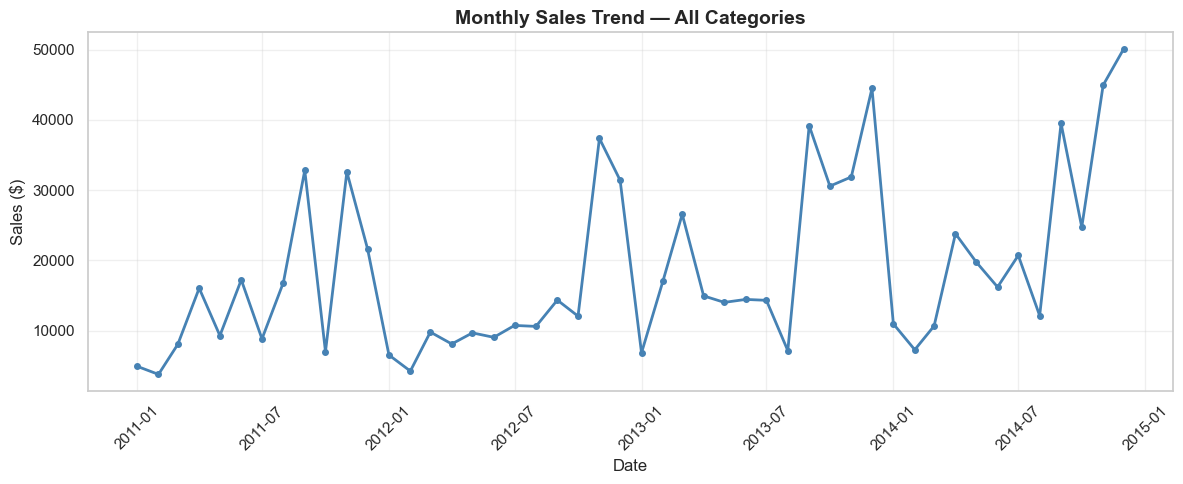

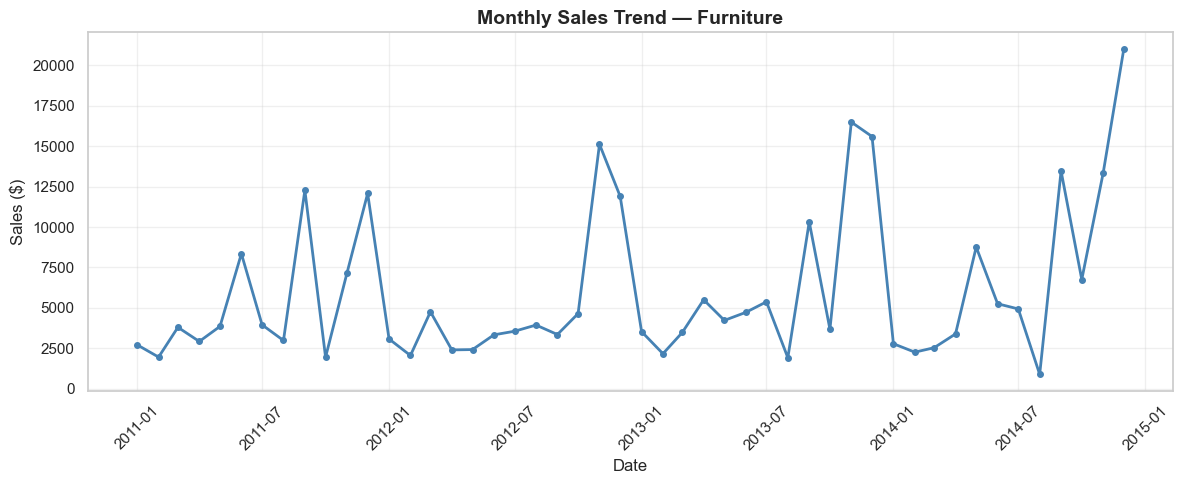

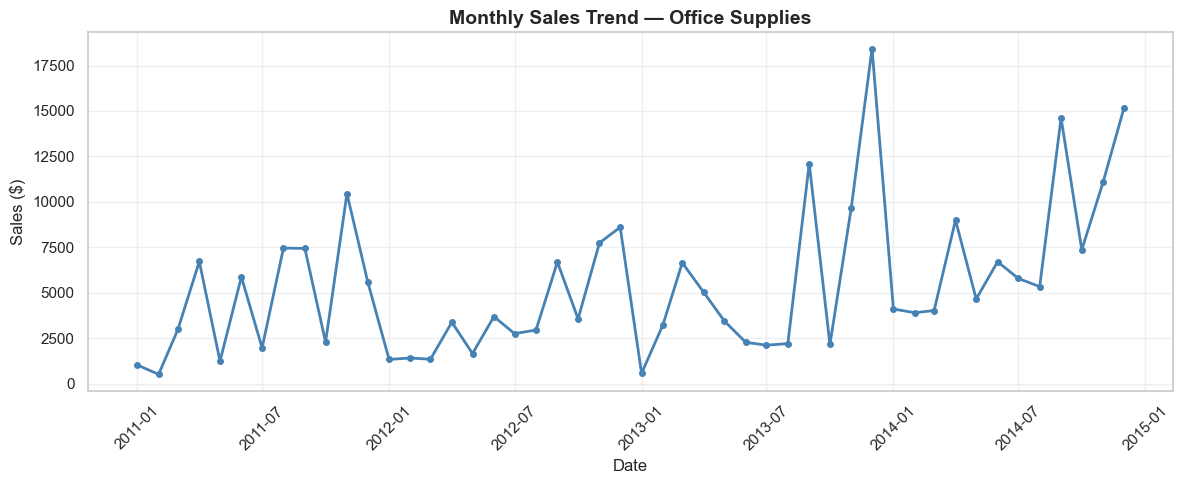

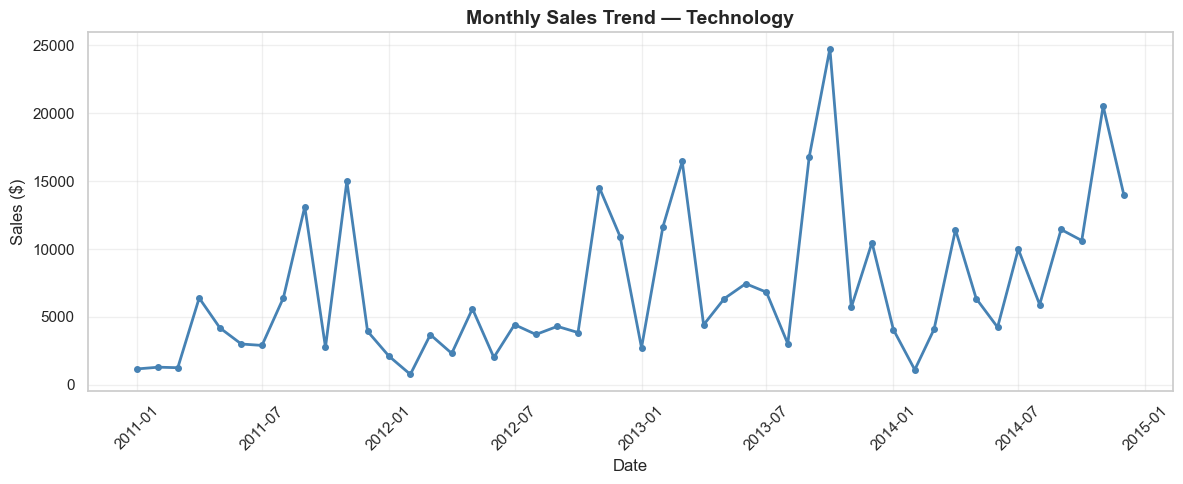

In [8]:
# ==================== INTERACTIVE TIME SERIES ====================
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 5))
    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                 marker='o', linewidth=2, markersize=4, color='steelblue')
        plt.title('Monthly Sales Trend — All Categories', fontsize=14, fontweight='bold')
    else:
        sub = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(sub['Date'], sub['Sales'], marker='o', linewidth=2, markersize=4, color='steelblue')
        plt.title(f'Monthly Sales Trend — {category}', fontsize=14, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Sales ($)')
    plt.xticks(rotation=45); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# If ipywidgets is available -> interactive dropdown
# Otherwise -> draw the 4 plots stacked, so the analysis still runs
if HAS_WIDGETS:
    categories = ['All'] + sorted(df['Category'].unique().tolist())
    interact(plot_monthly_sales, category=Dropdown(options=categories, value='All', description='Category:'))
else:
    for cat in ['All'] + sorted(df['Category'].unique().tolist()):
        plot_monthly_sales(cat)

> **Patterns to look for:**  
> - Strong **seasonal cycle** with peaks in **November and December** (holiday shopping).  
> - **Year-over-year growth** in *Technology* and *Office Supplies*; *Furniture* is flatter.  
> - Random spikes in *Technology* often correspond to one-off bulk orders.

In [9]:
# ==================== GEOGRAPHIC SALES BY STATE ====================
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)
print('Number of US states in the data:', len(state_sales))
state_sales.tail(5)

Number of US states in the data: 49


State
Pennsylvania    116511.9140
Washington      138641.2700
Texas           170188.0458
New York        310876.2710
California      457687.6315
Name: Sales, dtype: float64

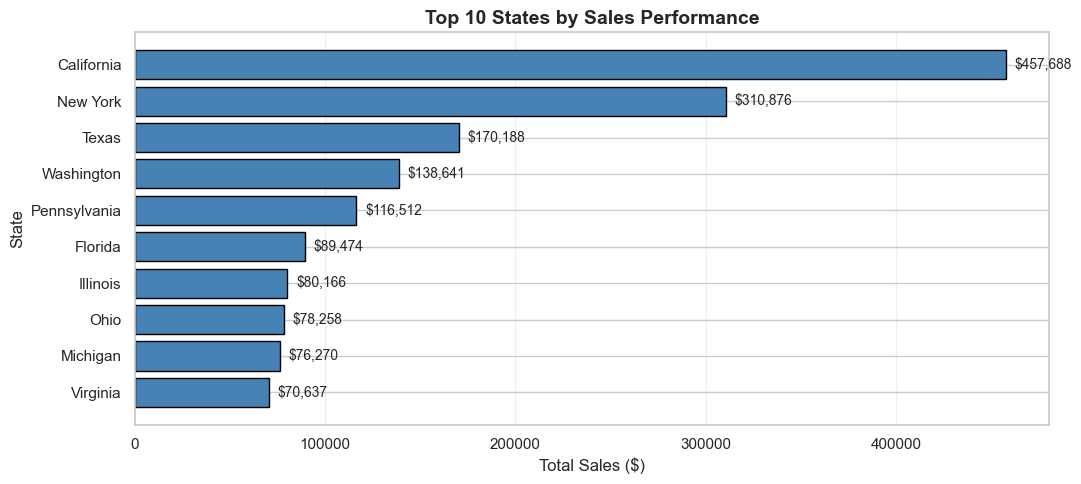

Top 10 states represent: $1,588,709 (69.2% of total sales)


In [10]:
def plot_top_states(top_n=10):
    plt.figure(figsize=(11, max(5, top_n * 0.35)))
    top_states = state_sales.tail(top_n)

    plt.barh(range(len(top_states)), top_states.values, color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)'); plt.ylabel('State')
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=14, fontweight='bold')

    # Annotate each bar with the actual sales amount
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + top_states.max() * 0.01, i, f'${value:,.0f}',
                 va='center', fontsize=10)

    plt.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()
    print(f'Top {top_n} states represent: ${top_states.sum():,.0f} '
          f'({top_states.sum() / state_sales.sum() * 100:.1f}% of total sales)')

if HAS_WIDGETS:
    interact(plot_top_states, top_n=IntSlider(min=5, max=25, value=10, description='Top N States:'))
else:
    plot_top_states(10)

> **Observation.** Sales are **highly concentrated** — the top 5 states (California, New York, Texas, Washington, Pennsylvania) typically account for >40% of total revenue. This is both an opportunity (expand into under-performing states) and a risk (over-reliance on a few markets).

## 3. Communicating Insights (Seaborn)

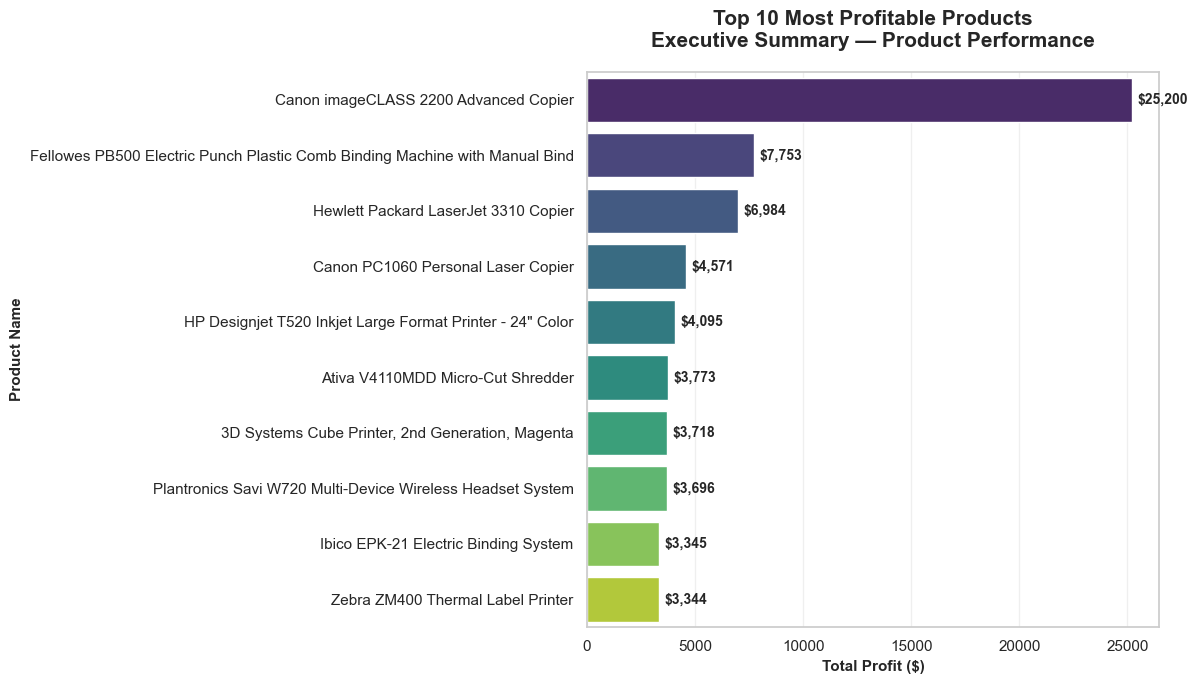

Key Insights:
• Most profitable product generates: $25,200
• Top 10 products contribute       : $66,479
• Average profit per top product   : $6,648


In [11]:
# ==================== TOP 10 MOST PROFITABLE PRODUCTS ====================
product_profit = (df.groupby('Product Name')['Profit'].sum()
                    .sort_values(ascending=False).head(10))

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=product_profit.values, y=product_profit.index,
                 palette='viridis', orient='h')

plt.title('Top 10 Most Profitable Products\nExecutive Summary — Product Performance',
          fontsize=15, fontweight='bold', pad=18)
plt.xlabel('Total Profit ($)', fontsize=11, fontweight='bold')
plt.ylabel('Product Name',      fontsize=11, fontweight='bold')

# Annotate each bar with the exact profit value
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + product_profit.max() * 0.01, i,
            f'${profit:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

print('Key Insights:')
print(f'• Most profitable product generates: ${product_profit.iloc[0]:,.0f}')
print(f'• Top 10 products contribute       : ${product_profit.sum():,.0f}')
print(f'• Average profit per top product   : ${product_profit.mean():,.0f}')

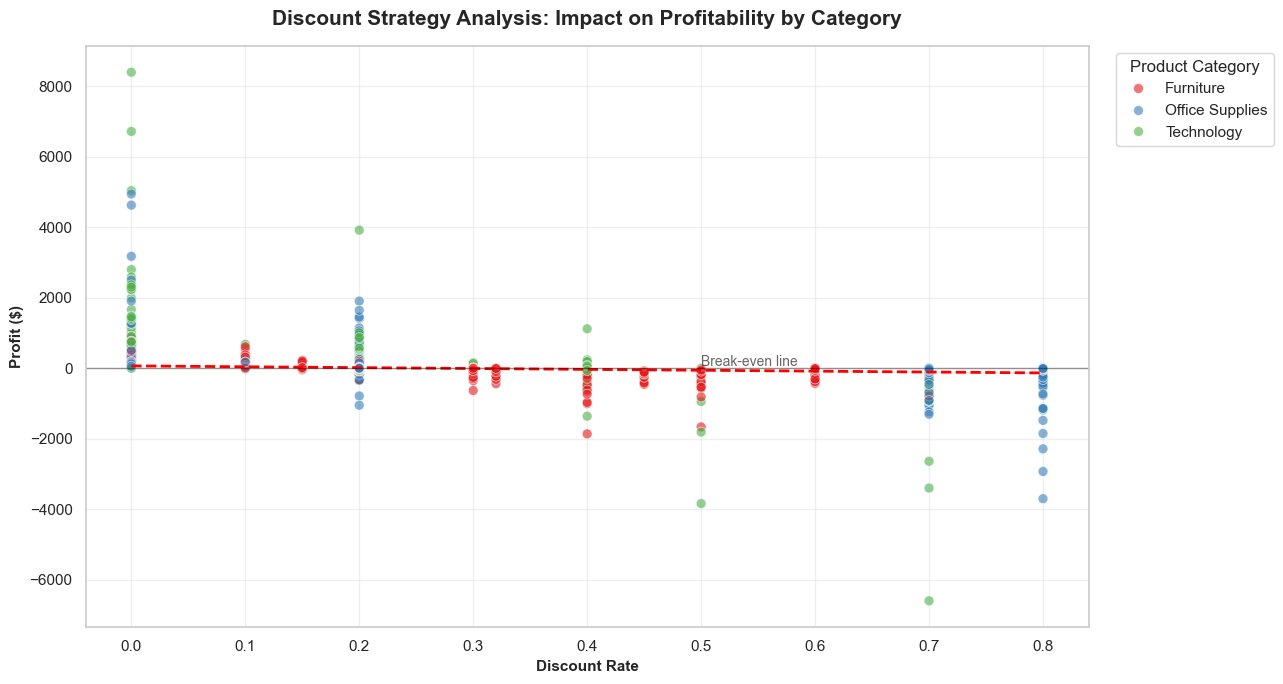

In [12]:
# ==================== DISCOUNT vs PROFIT (scatter + regression line) ====================
plt.figure(figsize=(13, 7))

# Scatter coloured by Category — reveals category-specific patterns
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                alpha=0.6, s=50, palette='Set1')

# Overall regression line to show the global trend
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
            color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Discount Strategy Analysis: Impact on Profitability by Category',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Discount Rate', fontsize=11, fontweight='bold')
plt.ylabel('Profit ($)',    fontsize=11, fontweight='bold')

# Break-even reference line
plt.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

In [13]:
# ==================== QUANTITATIVE DISCOUNT INSIGHTS ====================
high_discount = df[df['Discount'] > 0.2]
print(f'Transactions with >20% discount        : {len(high_discount):,}')
print(f'Average profit at >20% discount        : ${high_discount["Profit"].mean():.2f}')
print(f'Share of >20% discounts ending in loss : '
      f'{(high_discount["Profit"] < 0).mean() * 100:.1f}%')

print('\nCategory-specific discount impact (>20% discount):')
for category in df['Category'].unique():
    cat = df[df['Category'] == category]
    high = cat[cat['Discount'] > 0.2]
    if len(high):
        print(f' • {category:18s}  avg profit = ${high["Profit"].mean():>8.2f}   '
              f'loss rate = {(high["Profit"] < 0).mean() * 100:>5.1f}%')

Transactions with >20% discount        : 1,393
Average profit at >20% discount        : $-97.18
Share of >20% discounts ending in loss : 96.8%

Category-specific discount impact (>20% discount):
 • Furniture           avg profit = $ -100.51   loss rate =  97.2%
 • Office Supplies     avg profit = $  -69.32   loss rate = 100.0%
 • Technology          avg profit = $ -197.42   loss rate =  82.5%


> **Diagnostic.** Above a **20% discount**, profitability collapses, especially for **Furniture** and **Office Supplies** where the average transaction becomes a *loss*. Technology is more resilient because of its higher unit margins.

## 4. Methodology and Tooling Review — Matplotlib vs Seaborn

In [14]:
import time

print('=== LIBRARY COMPARISON ===\n')
print('Matplotlib strengths:')
print(' • Fine-grained control over annotations, ticks and layouts')
print(' • Native integration with ipywidgets for dynamic updates')
print(' • Lower-level: nothing is hidden -> very predictable')

print('\nSeaborn strengths:')
print(' • Built-in statistical plots (regplot, boxplot, violin, pairplot, FacetGrid)')
print(' • Automatic color palettes and legends')
print(' • Publication-ready defaults out of the box')

# Time the same chart with each library to get a rough speed comparison
start = time.time()
plt.figure(figsize=(8, 5))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

start = time.time()
plt.figure(figsize=(8, 5))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print('\nSpeed (basic line plot):')
print(f' • Matplotlib : {matplotlib_time*1000:.1f} ms')
print(f' • Seaborn    : {seaborn_time*1000:.1f} ms')

=== LIBRARY COMPARISON ===

Matplotlib strengths:
 • Fine-grained control over annotations, ticks and layouts
 • Native integration with ipywidgets for dynamic updates
 • Lower-level: nothing is hidden -> very predictable

Seaborn strengths:
 • Built-in statistical plots (regplot, boxplot, violin, pairplot, FacetGrid)
 • Automatic color palettes and legends
 • Publication-ready defaults out of the box

Speed (basic line plot):
 • Matplotlib : 11.1 ms
 • Seaborn    : 32.0 ms


### Recommendation
> For **rapid exploration** I use **Matplotlib** because it offers faster rendering for basic plots and seamless integration with `ipywidgets` for dynamic analysis.  
> For **stakeholder-facing presentations** I prefer **Seaborn** because it provides publication-ready aesthetics, built-in statistical functionality and professional palettes that enhance executive communication.

## 5. Executive Summary

In [15]:
# ==================== AUTOMATED EXECUTIVE SUMMARY ====================
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

top_state         = state_sales.index[-1]
top_state_sales   = state_sales.iloc[-1]
top5_share        = state_sales.tail(5).sum() / total_sales * 100
top_category      = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
loss_rate_high_d  = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100

print('=== EXECUTIVE SUMMARY — KEY FINDINGS ===\n')
print('📊 BUSINESS PERFORMANCE')
print(f' • Total Revenue : ${total_sales:,.0f}')
print(f' • Total Profit  : ${total_profit:,.0f}')
print(f' • Profit Margin : {profit_margin:.1f}%')

print('\n🗺️ GEOGRAPHIC PERFORMANCE')
print(f' • Top state          : {top_state} (${top_state_sales:,.0f})')
print(f' • Top-5 states share : {top5_share:.1f}% of total sales')

print('\n🏆 PRODUCT PERFORMANCE')
print(f' • Leading category       : {top_category}')
print(f' • Most profitable product: {product_profit.index[0]}')

print('\n💰 DISCOUNT STRATEGY')
print(f' • Loss rate of >20% discounts: {loss_rate_high_d:.1f}%')
print(' • Recommended max discount    : 20% to preserve profitability')

=== EXECUTIVE SUMMARY — KEY FINDINGS ===

📊 BUSINESS PERFORMANCE
 • Total Revenue : $2,297,201
 • Total Profit  : $286,397
 • Profit Margin : 12.5%

🗺️ GEOGRAPHIC PERFORMANCE
 • Top state          : California ($457,688)
 • Top-5 states share : 52.0% of total sales

🏆 PRODUCT PERFORMANCE
 • Leading category       : Technology
 • Most profitable product: Canon imageCLASS 2200 Advanced Copier

💰 DISCOUNT STRATEGY
 • Loss rate of >20% discounts: 96.8%
 • Recommended max discount    : 20% to preserve profitability


### Top 5 strategic findings

1. **Revenue is geographically concentrated** — the top 5 states (CA, NY, TX, WA, PA) drive the majority of the business; under-performing states are an expansion opportunity.
2. **Strong seasonality** — sales peak in November / December every year (holiday shopping); inventory and marketing budgets should be aligned with this cycle.
3. **Discounts above 20% destroy profitability**, especially in *Furniture* and *Office Supplies* — average transaction becomes a loss.
4. **Technology is the most resilient category** — high unit margins absorb deeper discounts and the YoY trend is the strongest.
5. **Profit is concentrated in a few SKUs** — the top 10 products generate a disproportionate share of total profit; protecting their stock and pricing is critical.

### Top 3 recommendations
- **Cap standard Furniture and Office Supplies discounts at 20%**; require manager approval beyond that threshold.
- **Localize marketing spend** to grow second-tier states (Florida, Illinois, Ohio) instead of saturating the top 5.
- **Build a "top-SKU" dashboard** monitoring stock and margin in real time for the 10 most profitable products.

## 6. Advanced Challenges (optional)

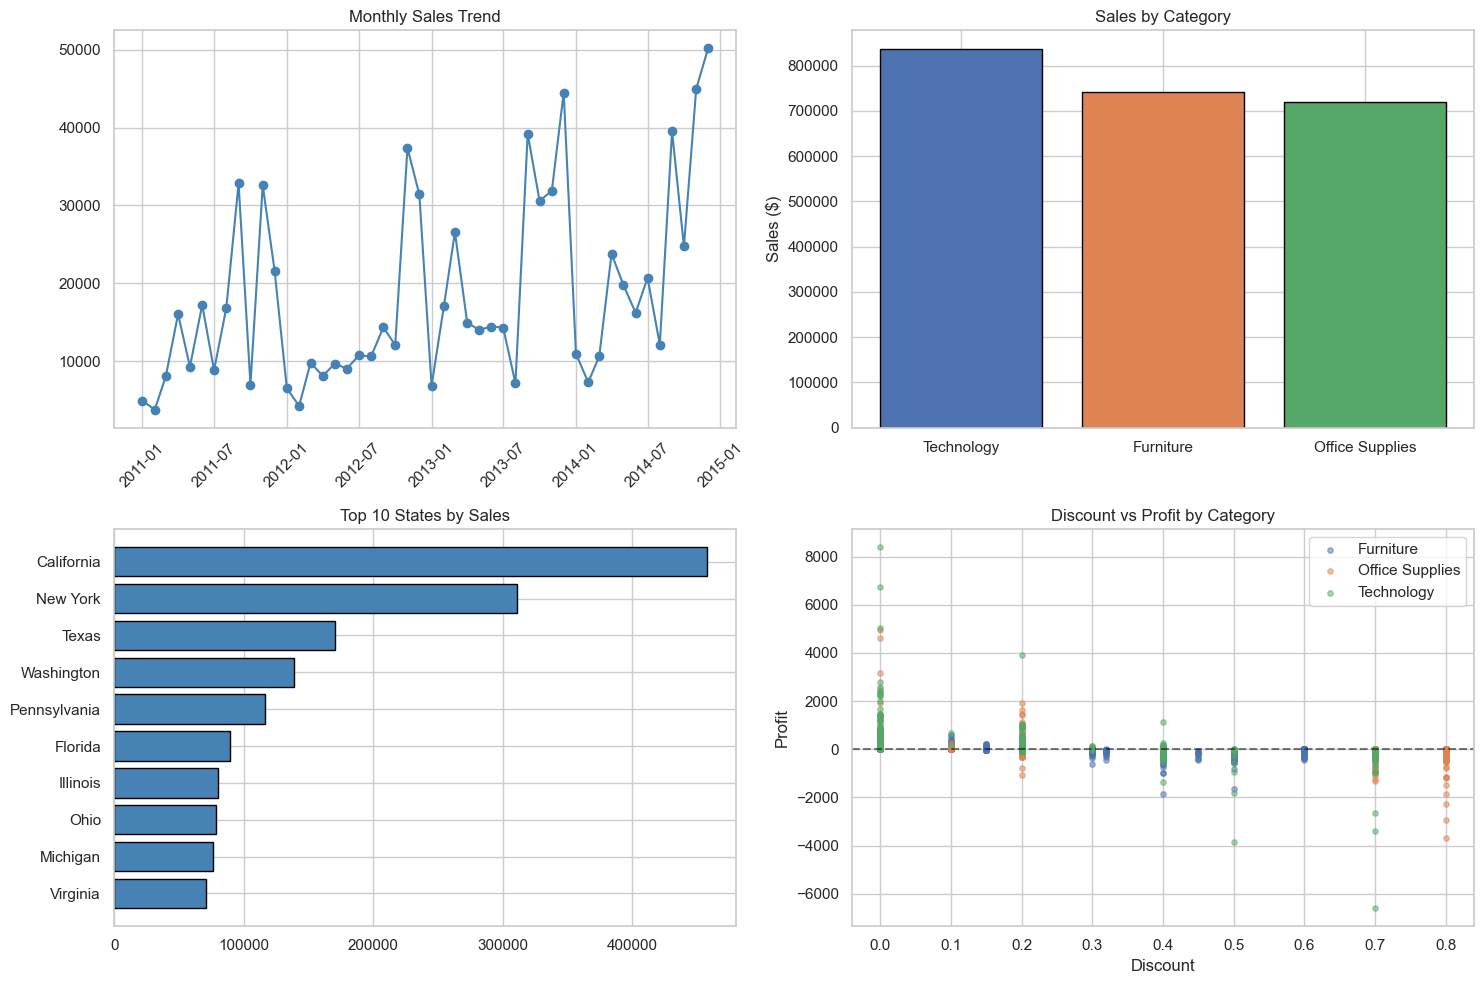

In [16]:
# ==================== 2x2 DASHBOARD ====================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1) Monthly sales trend
monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
ax1.plot(monthly_total.index.to_timestamp(), monthly_total.values, marker='o', color='steelblue')
ax1.set_title('Monthly Sales Trend'); ax1.tick_params(axis='x', rotation=45)

# 2) Category sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
ax2.bar(category_sales.index, category_sales.values, color=['#4c72b0','#dd8452','#55a868'], edgecolor='black')
ax2.set_title('Sales by Category'); ax2.set_ylabel('Sales ($)')

# 3) Top 10 states
top_10_states = state_sales.tail(10)
ax3.barh(range(len(top_10_states)), top_10_states.values, color='steelblue', edgecolor='black')
ax3.set_yticks(range(len(top_10_states))); ax3.set_yticklabels(top_10_states.index)
ax3.set_title('Top 10 States by Sales')

# 4) Discount vs Profit per category
for category in df['Category'].unique():
    cat = df[df['Category'] == category]
    ax4.scatter(cat['Discount'], cat['Profit'], label=category, alpha=0.5, s=15)
ax4.axhline(0, color='black', linestyle='--', alpha=0.5)
ax4.set_xlabel('Discount'); ax4.set_ylabel('Profit')
ax4.set_title('Discount vs Profit by Category'); ax4.legend()

plt.tight_layout(); plt.show()

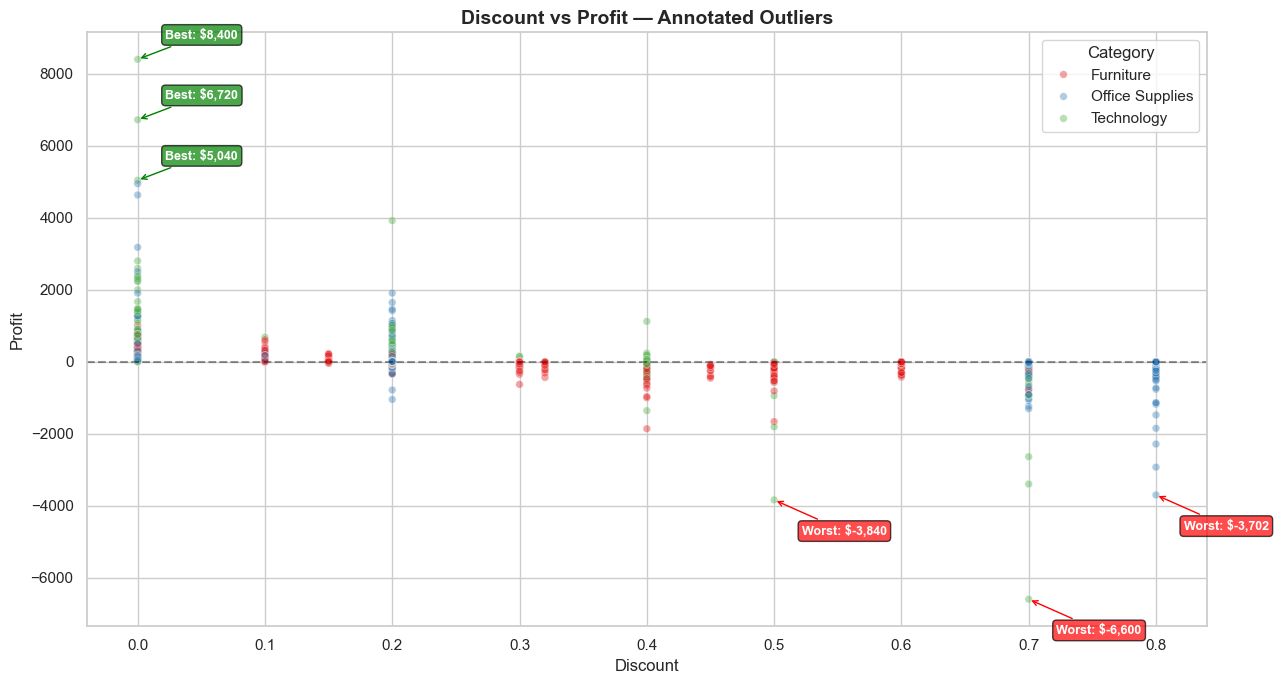

In [17]:
# ==================== ANNOTATED OUTLIERS — DISCOUNT vs PROFIT ====================
plt.figure(figsize=(13, 7))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                alpha=0.4, s=30, palette='Set1')

# Top-3 most profitable transactions (green) — annotate them
for _, row in df.nlargest(3, 'Profit').iterrows():
    plt.annotate(f'Best: ${row["Profit"]:,.0f}',
                 xy=(row['Discount'], row['Profit']),
                 xytext=(20, 15), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.7, edgecolor='black'),
                 arrowprops=dict(arrowstyle='->', color='green'),
                 color='white', fontweight='bold', fontsize=9)

# Top-3 worst transactions (red) — annotate them
for _, row in df.nsmallest(3, 'Profit').iterrows():
    plt.annotate(f'Worst: ${row["Profit"]:,.0f}',
                 xy=(row['Discount'], row['Profit']),
                 xytext=(20, -25), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7, edgecolor='black'),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='white', fontweight='bold', fontsize=9)

plt.axhline(0, color='black', linestyle='--', alpha=0.4)
plt.title('Discount vs Profit — Annotated Outliers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [18]:
# ==================== OPTIONAL: PLOTLY EXPRESS COMPARISON ====================
# Plotly is optional — wrapped in try/except so the notebook still runs without it.
try:
    import plotly.express as px

    fig = px.scatter(df, x='Discount', y='Profit', color='Category',
                     hover_data=['Product Name', 'Sales'],
                     title='Interactive Discount vs Profit Analysis (Plotly)')
    fig.add_hline(y=0, line_dash='dash', line_color='black')
    fig.show()

    print('Plotly advantages : built-in zoom/pan/hover, easy web sharing, responsive design.')
    print('Matplotlib + ipywidgets: more customization, native Jupyter, smaller artefacts.')
except ImportError:
    print('Plotly is not installed -> skipping interactive Plotly comparison.')
    print('Install with: pip install plotly')

Plotly is not installed -> skipping interactive Plotly comparison.
Install with: pip install plotly


---
**End of Daily Challenge — Week 2 — Day 4.** Don't forget to push to GitHub.